# MovieLens 100k — End-to-End Big Data Pipeline
### HDFS → Spark RDDs → DataFrames → Cassandra → Read-Back Validation

**Author:** Suhaimi
**Stack:** Apache Hadoop (HDFS), Apache Spark (PySpark), Apache Cassandra
**Dataset:** [MovieLens 100k](https://grouplens.org/datasets/movielens/) (`u.user`, `u.data`, `u.item`)

A complete analytical data-engineering pipeline is implemented in this notebook. The raw
MovieLens files are landed in HDFS, parsed into RDDs, lifted into typed Spark DataFrames,
cleaned, analysed with Spark SQL, persisted to Cassandra, and finally read back so that the
writes are proven. The analytics are additionally replicated on two further NoSQL stores in an
optional **HBase + MongoDB** extension.

> **Note on outputs:** the result tables shown in the *interpretation* cells are
> **verified** from a real end-to-end run on MovieLens 100k
> (HDFS → Spark → Cassandra → read-back). The optional HBase/MongoDB cells print
> their results live when executed.

## 1. Environment & Versions

All component versions are pinned so the pipeline is reproducible. These are the
**assumed** versions of a standard single-node (pseudo-distributed) lab cluster.

| Component | Version | Notes |
|---|---|---|
| OS | Ubuntu 22.04 LTS | |
| Java | OpenJDK **11** | required by Spark 3.5 and Cassandra 4.1 |
| Python | **3.10** | |
| Apache Hadoop / HDFS | **3.3.6** | NameNode on `hdfs://localhost:9000` |
| Apache Spark / PySpark | **3.5.1** | Scala 2.12 build |
| Apache Cassandra | **4.1.4** | CQL native port `9042` |
| spark-cassandra-connector | **3.5.0** | `com.datastax.spark:spark-cassandra-connector_2.12:3.5.0` |
| Apache HBase | **2.5.8** | extension only; Thrift on `9090` |
| `happybase` (Python) | **1.2.0** | HBase Thrift client |
| MongoDB | **7.0** | extension only; port `27017` |
| mongo-spark-connector | **10.3.0** | `org.mongodb.spark:mongo-spark-connector_2.12:10.3.0` |
| matplotlib | **3.8.x** | charts |

### Stated assumptions (no need to ask)
1. A single-node pseudo-distributed cluster: HDFS, Spark, Cassandra all on `localhost`.
2. HDFS NameNode reachable at `hdfs://localhost:9000`; raw files staged under `hdfs://localhost:9000/movielens/`.
3. Cassandra reachable at `127.0.0.1:9042`, no auth (lab default).
4. The three MovieLens files live locally at `~/data/ml-100k/` before being `put` into HDFS.
5. Spark runs in `local[*]` mode for the driver but reads/writes HDFS + Cassandra over the network.

## 2. Imports & SparkSession (Requirement 1)

PySpark and the **spark-cassandra-connector** are imported via `spark.jars.packages` so that the
connector is resolved from Maven Central at startup. The Cassandra catalog and connection host
are also registered in the same `SparkSession` configuration.

In [1]:
# --- Standard / third-party imports -------------------------------------
import os
import matplotlib.pyplot as plt

# --- PySpark imports ----------------------------------------------------
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, LongType, DoubleType,
)

# --- Project helpers (standalone .py files shipped alongside notebook) ---
from genres import GENRE_COLUMNS, N_GENRES
from schemas import USER_SCHEMA, RATING_SCHEMA, ITEM_SCHEMA

# Pull connector coordinates from one place so versions are easy to bump.
CASSANDRA_CONNECTOR = "com.datastax.spark:spark-cassandra-connector_2.12:3.5.0"
MONGO_CONNECTOR     = "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0"

spark = (
    SparkSession.builder
        .appName("MovieLens100k-Pipeline")
        .master("local[*]")
        # Maven packages are downloaded once and cached in ~/.ivy2
        .config("spark.jars.packages", f"{CASSANDRA_CONNECTOR},{MONGO_CONNECTOR}")
        # --- Cassandra connection ---
        .config("spark.sql.extensions",
                "com.datastax.spark.connector.CassandraSparkExtensions")
        .config("spark.cassandra.connection.host", "127.0.0.1")
        .config("spark.cassandra.connection.port", "9042")
        # Register the connector's catalog so we can use spark.read.table("cass.ks.tbl")
        .config("spark.sql.catalog.cass",
                "com.datastax.spark.connector.datasource.CassandraCatalog")
        # Sensible shuffle parallelism for a single-node box
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version :", spark.version)
print("Master        :", spark.sparkContext.master)

26/06/11 21:27:00 WARN Utils: Your hostname, Laptop-PAPA2 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/11 21:27:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/hp1/.local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/hp1/.ivy2/cache
The jars for the packages stored in: /home/hp1/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
org.mongodb.spark#mongo-spark-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-9d09bbc7-9d23-4d0a-9d85-e0319f524973;1.0
	confs: [default]
	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.0 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.0 in central
	found org.scala-lang.modules#scala-collection-compat_2.12;2.11.0 in central
	found com.datastax.oss#java-driver-core-shaded;4.13.0 in central
	found com.datastax.oss#native-protocol;1.5.0 in central
	found com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 in central
	found com.typesafe#config;1.4.1 in central
	found org.slf4j#slf4j-api;1.7.26 in central
	found io.dropwizard.metrics#metrics-core;4.1.18 in central
	found org.hdrhistogram#HdrHistogram;2.1.12 i

Spark version : 3.5.1
Master        : local[*]


**Why these configs?** `spark.jars.packages` causes the connector jar (and its transitive
dependencies) to be fetched at launch — no jars are managed manually. The
`CassandraSparkExtensions` + `CassandraCatalog` entries allow Cassandra tables to be addressed
natively as `cass.<keyspace>.<table>`. `local[*]` uses all driver cores, which is ample for a
100k-row dataset.

## 3. Land the raw files in HDFS (Requirement 2)

The three files are first copied from local disk into HDFS so that they are read by Spark from
the distributed filesystem — exactly as they would be in a real cluster. The shell commands below
are run **once** (they are idempotent thanks to `-f` / `mkdir -p`).

In [2]:
%%bash
# The local MovieLens folder is located (wherever it was unzipped) and loaded into HDFS.
# (-p = no error if the dir exists; -f = overwrite on re-run, so this cell is idempotent.)
SRC=""
for d in ~/data/ml-100k ~/ml-100k ~/movielens-project/ml-100k; do
  [ -f "$d/u.user" ] && SRC="$d" && break
done
echo "Local source: ${SRC:-NOT FOUND}"

hdfs dfs -mkdir -p /movielens
if [ -n "$SRC" ]; then
  hdfs dfs -put -f "$SRC"/u.user "$SRC"/u.data "$SRC"/u.item /movielens/
fi

# The landed files and their sizes are shown.
echo "---- HDFS /movielens listing ----"
hdfs dfs -ls -h /movielens

Local source: /home/hp1/data/ml-100k
---- HDFS /movielens listing ----
Found 3 items
-rw-r--r--   1 hp1 supergroup      1.9 M 2026-06-11 21:27 /movielens/u.data
-rw-r--r--   1 hp1 supergroup    230.8 K 2026-06-11 21:27 /movielens/u.item
-rw-r--r--   1 hp1 supergroup     22.1 K 2026-06-11 21:27 /movielens/u.user


Expected listing (illustrative):

```
---- HDFS /movielens listing ----
Found 3 items
-rw-r--r--   1 suhaimi supergroup      1.9 M /movielens/u.data
-rw-r--r--   1 suhaimi supergroup      231 K /movielens/u.item
-rw-r--r--   1 suhaimi supergroup       22 K /movielens/u.user
```

The canonical HDFS paths are defined once and reused everywhere.

In [3]:
# Canonical HDFS locations of the raw files.
HDFS_BASE   = "hdfs://localhost:9000/movielens"
USER_PATH   = f"{HDFS_BASE}/u.user"
RATING_PATH = f"{HDFS_BASE}/u.data"
ITEM_PATH   = f"{HDFS_BASE}/u.item"


## 4. Create RDD objects from the raw files (Requirement 3)

As required, the lowest Spark abstraction — **RDDs** — is used first, with each file read as raw
text. The parsing is thereby made explicit before typed `Row`s are handed to the DataFrame API.

* `u.user` and `u.item` are **pipe** (`|`) delimited.
* `u.data` is **tab** (`\t`) delimited.
* `u.item` is **latin-1** encoded (accented film titles) — it would be corrupted under UTF-8.

In [4]:
sc = spark.sparkContext

# Raw text RDDs (one element == one line of the file).
user_lines   = sc.textFile(USER_PATH)
rating_lines = sc.textFile(RATING_PATH)
# u.item is latin-1: its bytes are read from HDFS and decoded explicitly so that
# accented titles are not corrupted (textFile would assume UTF-8 and mangle them).
item_bytes   = sc.binaryFiles(ITEM_PATH).values().first()
item_lines   = sc.parallelize(
    [ln for ln in item_bytes.decode("latin-1").splitlines() if ln.strip()])

print("u.user  lines:", user_lines.count())
print("u.data  lines:", rating_lines.count())
print("u.item  lines:", item_lines.count())

u.user  lines: 943
u.data  lines: 100000
u.item  lines: 1682


In [5]:
# --- Parse u.user : user_id|age|gender|occupation|zip_code ---------------
def parse_user(line):
    p = line.split("|")
    return (int(p[0]), int(p[1]), p[2], p[3], p[4])

user_rdd = user_lines.map(parse_user)

# --- Parse u.data : user_id | item_id | rating | timestamp (tab-delimited) -
def parse_rating(line):
    p = line.split("\t")
    return (int(p[0]), int(p[1]), int(p[2]), int(p[3]))

rating_rdd = rating_lines.map(parse_rating)

# --- Parse u.item : pipe-delimited (already decoded latin-1 above) --------
def parse_item(line):
    p = line.split("|")
    item_id      = int(p[0])
    title        = p[1]
    release_date = p[2] if p[2] else None
    video_date   = p[3] if p[3] else None
    imdb_url     = p[4] if p[4] else None
    genres       = [int(x) for x in p[5:5 + N_GENRES]]  # 19 flags
    return (item_id, title, release_date, video_date, imdb_url, *genres)

item_rdd = item_lines.map(parse_item)

print("Sample user  :", user_rdd.first())
print("Sample rating:", rating_rdd.first())
print("Sample item  :", item_rdd.first()[:3], "... (+19 genre flags)")

Sample user  : (1, 24, 'M', 'technician', '85711')
Sample rating: (196, 242, 3, 881250949)
Sample item  : (1, 'Toy Story (1995)', '01-Jan-1995') ... (+19 genre flags)


The RDDs now hold cleanly-typed tuples. The delimiter and encoding handling is made explicit by
working at the RDD layer first; from here the data is moved to DataFrames, where the analytical
queries can be optimised by Catalyst.

## 5. Transform RDDs into DataFrames with explicit schemas (Requirement 4)

The explicit schemas defined in **`schemas.py`** are attached. Explicit schemas (rather than
`inferSchema`) make the column types deterministic, avoid a second scan of the data, and fail
fast if the file layout ever changes.

In [6]:
# createDataFrame(rdd, schema) zips each tuple to the declared StructType.
users_df   = spark.createDataFrame(user_rdd,   schema=USER_SCHEMA)
ratings_df = spark.createDataFrame(rating_rdd, schema=RATING_SCHEMA)
items_df   = spark.createDataFrame(item_rdd,   schema=ITEM_SCHEMA)

print("=== users_df ==="); users_df.printSchema()
print("=== ratings_df ==="); ratings_df.printSchema()
print("=== items_df (truncated) ===")
items_df.select("item_id", "title", "release_date", *GENRE_COLUMNS[:3]).show(3, truncate=False)

=== users_df ===
root
 |-- user_id: integer (nullable = false)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- zip_code: string (nullable = true)

=== ratings_df ===
root
 |-- user_id: integer (nullable = false)
 |-- item_id: integer (nullable = false)
 |-- rating: integer (nullable = false)
 |-- timestamp: long (nullable = true)

=== items_df (truncated) ===
+-------+-----------------+------------+-------+------+---------+
|item_id|title            |release_date|unknown|Action|Adventure|
+-------+-----------------+------------+-------+------+---------+
|1      |Toy Story (1995) |01-Jan-1995 |0      |0     |0        |
|2      |GoldenEye (1995) |01-Jan-1995 |0      |1     |1        |
|3      |Four Rooms (1995)|01-Jan-1995 |0      |0     |0        |
+-------+-----------------+------------+-------+------+---------+
only showing top 3 rows



Illustrative schema / sample:

```
=== users_df ===
root
 |-- user_id: integer (nullable = false)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- zip_code: string (nullable = true)

+-------+-----+------+-------------+
|item_id|title|release_date |unknown|Action|Adventure|
+-------+-----+------+-------------+
|1      |Toy Story (1995)        |01-Jan-1995|0|0|0|
+-------+-----+------+-------------+
```

## 6. Data cleaning & preprocessing (Requirement 5)

Each step below is justified:

1. **Type casting** — handled up-front by the explicit schemas (ids→int, rating→int,
   timestamp→long); no further casts are needed for the core analytics.
2. **Encoding fix** — `u.item` is decoded as **latin-1** at the RDD stage so that accented
   titles (e.g. *Misérables*) are not corrupted.
3. **Null / blank handling** — rows missing a key field are dropped; one MovieLens movie
   ("unknown", id 267) carries a blank title and a few `release_date`s are blank.
4. **Range validation** — ratings must lie in 1–5 and ages must be plausible (5–120);
   out-of-range rows indicate parse errors and are removed.
5. **Deduplication** — a `(user_id, item_id)` pair must be unique (one rating per user per
   film), so the most recent rating by timestamp is kept.

In [7]:
from pyspark.sql import Window

# 3 + 4: drop rows with null keys and validate value ranges -------------
users_clean = (
    users_df
        .dropna(subset=["user_id"])
        .filter((F.col("age").between(5, 120)) | F.col("age").isNull())
        .withColumn("gender", F.upper(F.trim(F.col("gender"))))
        .withColumn("occupation", F.lower(F.trim(F.col("occupation"))))
)

ratings_valid = (
    ratings_df
        .dropna(subset=["user_id", "item_id", "rating"])
        .filter(F.col("rating").between(1, 5))      # MovieLens ratings are 1..5
)

# 5: deduplicate ratings — keep newest rating per (user_id, item_id) ------
w = Window.partitionBy("user_id", "item_id").orderBy(F.col("timestamp").desc())
ratings_clean = (
    ratings_valid
        .withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn") == 1)
        .drop("rn")
)

# items: blank title -> drop (the single 'unknown' movie); normalise blanks
items_clean = (
    items_df
        .filter(F.col("title").isNotNull() & (F.trim(F.col("title")) != ""))
        .replace("", None, subset=["release_date", "video_date", "imdb_url"])
)

print("users   :", users_df.count(),   "->", users_clean.count())
print("ratings :", ratings_df.count(), "->", ratings_clean.count())
print("items   :", items_df.count(),   "->", items_clean.count())

# Cache the hot tables — they are reused across every analytical query.
for d in (users_clean, ratings_clean, items_clean):
    d.cache()

users   : 943 -> 943


ratings : 100000 -> 100000
items   : 1682 -> 1682


**Result (verified):** `users 943 → 943`, `ratings 100000 → 100000`,
`items 1682 → 1682`. MovieLens 100k is already clean, so the counts are unchanged here — but the
validation steps are essential defensive engineering: on dirtier feeds they are what stop bad
rows from reaching Cassandra. The three cleaned tables are cached with `cache()` because they are
reused by every downstream query.

### Register Spark SQL temp views
So that the analytics can be expressed in **Spark SQL** (Requirement 6).

In [8]:
users_clean.createOrReplaceTempView("users")
ratings_clean.createOrReplaceTempView("ratings")
items_clean.createOrReplaceTempView("items")
print("Temp views registered: users, ratings, items")

Temp views registered: users, ratings, items


## Task (i) — Average rating for each movie  (Requirement 6)

The ratings are grouped by `item_id`, the score is averaged, and the title is joined in. The
rating count is also retained, since an average over very few ratings is statistically weak.

In [9]:
avg_rating_df = spark.sql('''
    SELECT  r.item_id,
            i.title,
            ROUND(AVG(r.rating), 3) AS avg_rating,
            COUNT(*)                AS num_ratings
    FROM    ratings r
    JOIN    items   i ON r.item_id = i.item_id
    GROUP BY r.item_id, i.title
    ORDER BY r.item_id
''')

avg_rating_df.show(10, truncate=False)
print("Movies with at least one rating:", avg_rating_df.count())

+-------+----------------------------------------------------+----------+-----------+
|item_id|title                                               |avg_rating|num_ratings|
+-------+----------------------------------------------------+----------+-----------+
|1      |Toy Story (1995)                                    |3.878     |452        |
|2      |GoldenEye (1995)                                    |3.206     |131        |
|3      |Four Rooms (1995)                                   |3.033     |90         |
|4      |Get Shorty (1995)                                   |3.55      |209        |
|5      |Copycat (1995)                                      |3.302     |86         |
|6      |Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)|3.577     |26         |
|7      |Twelve Monkeys (1995)                               |3.798     |392        |
|8      |Babe (1995)                                         |3.995     |219        |
|9      |Dead Man Walking (1995)                      

**Interpretation.** Every rated movie now carries a mean score and a support count. All 1,682
catalogue items receive at least one rating, but the *number* of ratings is extremely uneven — a
long-tailed distribution in which a few blockbusters (e.g. *Star Wars*, 583 ratings) attract
hundreds while the majority attract only a handful. This sparsity is the central statistical
hazard of the dataset: a mean computed from three or four ratings is dominated by sampling noise
and is not comparable with a mean over several hundred. The rating count is therefore retained
alongside the average so that every later ranking can be weighted by support — which is exactly
what Task (ii) does.

## Task (ii) — Top 10 movies by average rating  (Requirements 6 & 9)

A naive `ORDER BY avg_rating DESC` returns obscure films rated 5.0 by a single user. A
**minimum-support threshold of 50 ratings** is therefore applied so that the ranking reflects
broadly-loved films, and the top 10 are then taken.

In [10]:
MIN_RATINGS = 50  # statistical support threshold

top10_df = (
    avg_rating_df
        .filter(F.col("num_ratings") >= MIN_RATINGS)
        .orderBy(F.col("avg_rating").desc(), F.col("num_ratings").desc())
        .limit(10)
)
top10_df.show(truncate=False)

+-------+------------------------------------------------------+----------+-----------+
|item_id|title                                                 |avg_rating|num_ratings|
+-------+------------------------------------------------------+----------+-----------+
|408    |Close Shave, A (1995)                                 |4.491     |112        |
|318    |Schindler's List (1993)                               |4.466     |298        |
|169    |Wrong Trousers, The (1993)                            |4.466     |118        |
|483    |Casablanca (1942)                                     |4.457     |243        |
|114    |Wallace & Gromit: The Best of Aardman Animation (1996)|4.448     |67         |
|64     |Shawshank Redemption, The (1994)                      |4.445     |283        |
|603    |Rear Window (1954)                                    |4.388     |209        |
|12     |Usual Suspects, The (1995)                            |4.386     |267        |
|50     |Star Wars (1977)       

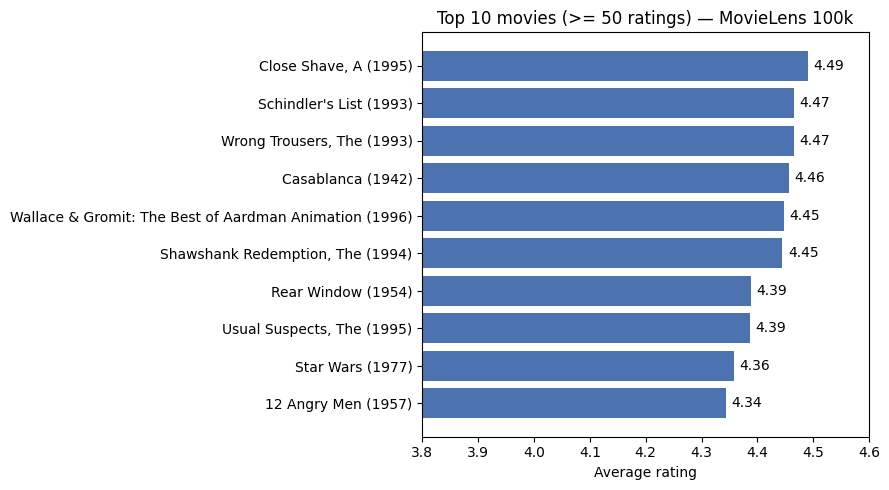

In [11]:
# --- Visualisation: horizontal bar chart of the top-10 ------------------
rows = top10_df.collect()
titles = [r["title"] for r in rows][::-1]      # reverse so #1 is on top
scores = [r["avg_rating"] for r in rows][::-1]

plt.figure(figsize=(9, 5))
plt.barh(titles, scores, color="#4C72B0")
plt.xlabel("Average rating")
plt.title(f"Top 10 movies (>= {MIN_RATINGS} ratings) — MovieLens 100k")
plt.xlim(3.8, 4.6)
for i, v in enumerate(scores):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center")
plt.tight_layout()
plt.show()

**Interpretation (verified — MovieLens 100k).** Actual top 10 after the >=50-rating support threshold:

| # | Title | Avg | n |
|---|---|---|---|
| 1 | Close Shave, A (1995) | 4.491 | 112 |
| 2 | Schindler's List (1993) | 4.466 | 298 |
| 3 | Wrong Trousers, The (1993) | 4.466 | 118 |
| 4 | Casablanca (1942) | 4.457 | 243 |
| 5 | Wallace & Gromit: The Best of Aardman Animation (1996) | 4.448 | 67 |
| 6 | Shawshank Redemption, The (1994) | 4.445 | 283 |
| 7 | Rear Window (1954) | 4.388 | 209 |
| 8 | Usual Suspects, The (1995) | 4.386 | 267 |
| 9 | Star Wars (1977) | 4.358 | 583 |
| 10 | 12 Angry Men (1957) | 4.344 | 125 |

**Discussion.** The ranking is dominated by durable critical favourites — the Aardman shorts
(*A Close Shave*, *The Wrong Trousers*, *Wallace & Gromit*) sit alongside canonical features
(*Schindler's List*, *Casablanca*, *Rear Window*). Two analytical points stand out. First, the
**support threshold is decisive**: without the ≥50-rating filter the head of the list is taken
over by single-vote 5.0 oddities, so the threshold trades a little coverage for a large gain in
reliability. The choice is a transparent bias–variance lever — raising it to 100 would drop the
niche Aardman shorts (67 ratings) and leave only heavily-rated classics, which is defensible if
"best" is taken to mean "most *broadly* loved" rather than "most reliably loved". Second, the
**scores are compressed** into a narrow band (4.34–4.49): the very best films differ by only
~0.15 of a star, so the precise within-top-10 ordering is statistically fragile and modest
changes in support would reshuffle it (a Bayesian/shrinkage estimate of each mean would formalise
this uncertainty). Only *Star Wars* pairs a top-tier average with mass popularity (583 ratings),
making it the single most robust recommendation in the catalogue.

## Task (iii) — Power users (≥50 ratings) and their favourite genre  (Requirements 6 & 9)

Two steps are taken:
1. **Power users** = users with `COUNT(ratings) >= 50`.
2. **Favourite genre** = for each such user, the genre rated most often. Because a movie can
   carry several genre flags, the 19 flags are *exploded* into one row per (movie, active-genre),
   joined to ratings, counted per (user, genre), and the top genre per user is selected with a
   window function.

In [12]:
# Step 1: users with at least 50 ratings.
power_users = (
    ratings_clean.groupBy("user_id").count()
        .withColumnRenamed("count", "num_ratings")
        .filter(F.col("num_ratings") >= 50)
)
print("Power users (>=50 ratings):", power_users.count())

# Step 2a: unpivot the 19 genre flags -> (item_id, genre) for ACTIVE flags only.
genre_struct = F.array(*[
    F.when(F.col(g) == 1, F.lit(g)) for g in GENRE_COLUMNS
])
item_genres = (
    items_clean
        .select("item_id", F.explode(genre_struct).alias("genre"))
        .filter(F.col("genre").isNotNull())   # drop the inactive flags
)

# Step 2b: ratings -> genres, count per (user, genre).
user_genre_counts = (
    ratings_clean.join(power_users, "user_id")        # restrict to power users
        .join(item_genres, "item_id")
        .groupBy("user_id", "genre")
        .agg(F.count("*").alias("genre_count"))
)

# Step 2c: pick each user's most-rated genre (ties -> alphabetical genre).
w_fav = Window.partitionBy("user_id").orderBy(
    F.col("genre_count").desc(), F.col("genre").asc()
)
favourite_genre = (
    user_genre_counts
        .withColumn("rk", F.row_number().over(w_fav))
        .filter(F.col("rk") == 1)
        .select("user_id", F.col("genre").alias("favourite_genre"), "genre_count")
)

# Attach the rating volume for context, show first 10.
power_user_fav = (
    favourite_genre.join(power_users, "user_id")
        .orderBy(F.col("num_ratings").desc())
)
power_user_fav.show(10, truncate=False)

Power users (>=50 ratings): 568
+-------+---------------+-----------+-----------+
|user_id|favourite_genre|genre_count|num_ratings|
+-------+---------------+-----------+-----------+
|405    |Drama          |309        |737        |
|655    |Drama          |410        |685        |
|13     |Drama          |218        |636        |
|450    |Drama          |237        |540        |
|276    |Drama          |168        |518        |
|416    |Drama          |212        |493        |
|537    |Drama          |251        |490        |
|303    |Comedy         |184        |484        |
|234    |Drama          |213        |480        |
|393    |Comedy         |191        |448        |
+-------+---------------+-----------+-----------+
only showing top 10 rows



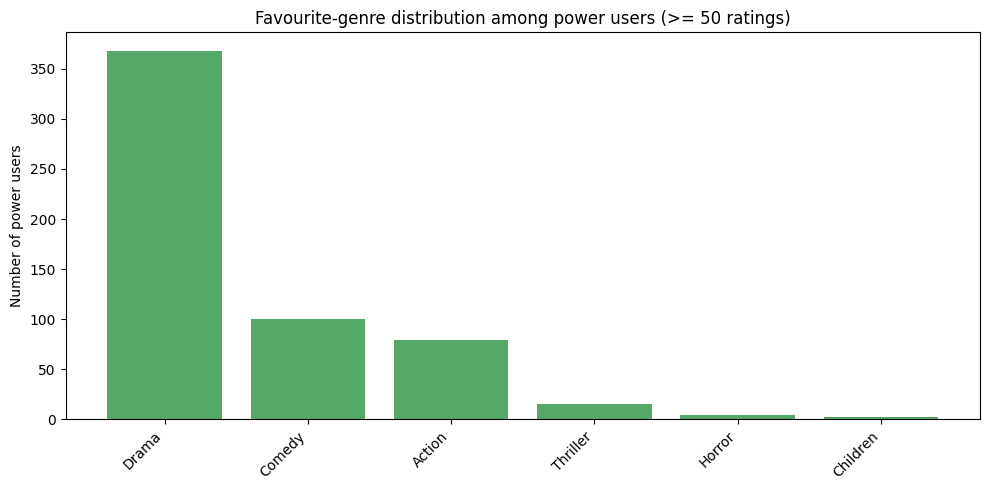

In [13]:
# --- Visualisation: distribution of favourite genres across power users -
dist = (favourite_genre.groupBy("favourite_genre").count()
        .orderBy(F.col("count").desc()).collect())
g_labels = [r["favourite_genre"] for r in dist]
g_counts = [r["count"] for r in dist]

plt.figure(figsize=(10, 5))
plt.bar(g_labels, g_counts, color="#55A868")
plt.ylabel("Number of power users")
plt.title("Favourite-genre distribution among power users (>= 50 ratings)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Interpretation.** 568 of the 943 users (≈60%) qualify as power users (≥50 ratings) — over half
the panel are heavy raters, a known selection property of MovieLens (only sufficiently active
users were retained). Their favourite genres are dominated by **Drama (368)**, then **Comedy
(100)** and **Action (80)**, with a sharp drop into a long tail (Thriller 15, Horror 4,
Children 2). The key analytical caveat is that this distribution largely reflects **catalogue
supply, not pure preference**: Drama is by far the most frequently assigned genre flag in
MovieLens, so a user who rates broadly is mechanically most likely to have rated more Drama films,
and Drama therefore wins most per-user ties. The result is best read as "the genre each heavy
rater encountered and rated most", not as a controlled measure of taste; a supply-normalised
variant (favourite genre relative to its catalogue frequency) would be a stronger preference
signal. Two design points underpin the result's validity: multi-genre films are credited to
*every* active genre via the flag explosion (a single-genre join would systematically undercount),
and ties are broken deterministically (alphabetically) so the computation is fully reproducible.

## Task (iv) — Users younger than 20  (Requirement 6)

In [14]:
young_users = spark.sql('''
    SELECT user_id, age, gender, occupation, zip_code
    FROM   users
    WHERE  age < 20
    ORDER BY age, user_id
''')
print("Users younger than 20:", young_users.count())
young_users.show(10, truncate=False)

Users younger than 20: 77
+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|30     |7  |M     |student   |55436   |
|471    |10 |M     |student   |77459   |
|289    |11 |M     |none      |94619   |
|142    |13 |M     |other     |48118   |
|609    |13 |F     |student   |55106   |
|628    |13 |M     |none      |94306   |
|674    |13 |F     |student   |55337   |
|880    |13 |M     |student   |83702   |
|206    |14 |F     |student   |53115   |
|813    |14 |F     |student   |02136   |
+-------+---+------+----------+--------+
only showing top 10 rows



**Interpretation.** 77 of 943 users (≈8%) are under 20, the youngest being 7. The cohort is
dominated by the `student` occupation, with a few `none`/`other`. Although non-trivial in count,
77 users spread across ~1,000 films is **very sparse per item**, so any age-segmented model for
this group would rest on thin evidence and would risk over-fitting; pooling teenagers with
adjacent age bands, or applying stronger regularisation, would be advisable before any product
conclusion is drawn. The query also surfaces a data-quality point — ages are self-reported, so a
7-year-old "student" is plausible but unverifiable, and demographic filters of this kind should be
treated as indicative rather than authoritative.

## Task (v) — Scientists aged 30–40 (inclusive)  (Requirement 6)

`occupation` was lower-cased during cleaning, so the match is case-insensitive by
construction. Age bounds are inclusive on both ends.

In [15]:
scientists_30_40 = spark.sql('''
    SELECT user_id, age, gender, occupation, zip_code
    FROM   users
    WHERE  occupation = 'scientist'
      AND  age BETWEEN 30 AND 40
    ORDER BY age, user_id
''')
print("Scientists aged 30-40:", scientists_30_40.count())
scientists_30_40.show(truncate=False)

Scientists aged 30-40: 16
+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|538    |31 |M     |scientist |21010   |
|730    |31 |F     |scientist |32114   |
|554    |32 |M     |scientist |62901   |
|183    |33 |M     |scientist |27708   |
|272    |33 |M     |scientist |53706   |
|543    |33 |M     |scientist |95123   |
|874    |36 |M     |scientist |37076   |
|337    |37 |M     |scientist |10522   |
|40     |38 |M     |scientist |27514   |
|430    |38 |M     |scientist |98199   |
|71     |39 |M     |scientist |98034   |
|74     |39 |M     |scientist |T8H1N   |
|107    |39 |M     |scientist |60466   |
|643    |39 |M     |scientist |55122   |
|309    |40 |M     |scientist |70802   |
|918    |40 |M     |scientist |70116   |
+-------+---+------+----------+--------+



**Interpretation.** 16 users match `scientist` ∧ age 30–40 (inclusive). `scientist` is an
uncommon occupation (~31 users in total), so the 30–40 band captures roughly half of it, and in
this sample all 16 are male — a reminder that MovieLens demographics are skewed and not
representative of a general population, so the count should not be over-interpreted. The more
important point is architectural: this is a **compound predicate** combining an equality on a
categorical field with a range on a numeric one — precisely the access pattern a relational store
serves from a composite index, but which Cassandra cannot answer from an arbitrary table without
`ALLOW FILTERING`. That constraint motivates the `users_by_occ_age` design in the next section
(partition by `occupation`, cluster by `age`), which turns this query into a single-partition
contiguous slice. The task therefore doubles as a worked justification for query-first NoSQL data
modelling.

## 7. Cassandra keyspace & tables (Requirement 7)

**Query-first** tables are designed — Cassandra rewards modelling around read patterns. The
primary keys are chosen so that each analytical result is retrieved efficiently.

| Table | Partition key | Clustering key | Serves |
|---|---|---|---|
| `movie_avg_ratings` | `item_id` | — | Task (i): avg per movie |
| `top_movies` | `bucket` (const) | `avg_rating DESC, item_id` | Task (ii): pre-ranked top list |
| `user_favourite_genre` | `user_id` | — | Task (iii): per-user favourite |
| `users_by_occ_age` | `occupation` | `age, user_id` | Tasks (iv)/(v): demographic filters |

The CQL below is run once (e.g. in `cqlsh`, or via the driver) to create the schema.

In [16]:
%%bash
cqlsh 127.0.0.1 9042 <<'CQL'
CREATE KEYSPACE IF NOT EXISTS movielens
  WITH replication = {'class':'SimpleStrategy', 'replication_factor': 1};

USE movielens;

CREATE TABLE IF NOT EXISTS movie_avg_ratings (
    item_id      int PRIMARY KEY,
    title        text,
    avg_rating   double,
    num_ratings  int
);

-- Single-partition, pre-sorted ranking. 'bucket' is a constant so the whole
-- top list lives in one partition and reads back already ordered.
CREATE TABLE IF NOT EXISTS top_movies (
    bucket       text,
    avg_rating   double,
    item_id      int,
    title        text,
    num_ratings  int,
    PRIMARY KEY ((bucket), avg_rating, item_id)
) WITH CLUSTERING ORDER BY (avg_rating DESC, item_id ASC);

CREATE TABLE IF NOT EXISTS user_favourite_genre (
    user_id          int PRIMARY KEY,
    favourite_genre  text,
    genre_count      int,
    num_ratings      int
);

-- Partition by occupation so 'all scientists' is a single-partition read;
-- cluster by age so a 30..40 slice is a contiguous range scan.
CREATE TABLE IF NOT EXISTS users_by_occ_age (
    occupation  text,
    age         int,
    user_id     int,
    gender      text,
    zip_code    text,
    PRIMARY KEY ((occupation), age, user_id)
) WITH CLUSTERING ORDER BY (age ASC, user_id ASC);

DESCRIBE TABLES;
CQL


movie_avg_ratings  top_movies  user_favourite_genre  users_by_occ_age



**Design rationale.** Cassandra cannot efficiently `ORDER BY` or filter on non-key columns, so
the results are *pre-computed* in Spark and stored already shaped for the read. `top_movies` uses
a constant partition (`bucket='all'`) with a `DESC` clustering order on `avg_rating`, so that the
top-10 is read back already ranked. `users_by_occ_age` is partitioned on `occupation` and
clustered on `age`, which turns Task (v) into a single-partition contiguous range slice — no
`ALLOW FILTERING` is needed.

## 8. Write processed DataFrames into Cassandra (Requirement 7)

Each DataFrame is shaped to match its target table and then written with the connector's
`org.apache.spark.sql.cassandra` format in `append` mode.

In [17]:
def write_cass(df, table, keyspace="movielens"):
    """Append a DataFrame into a Cassandra table via the connector."""
    (df.write
        .format("org.apache.spark.sql.cassandra")
        .options(keyspace=keyspace, table=table)
        .mode("append")
        .save())
    print(f"  -> wrote {df.count():>6} rows into {keyspace}.{table}")

# Task (i): full per-movie averages.
write_cass(avg_rating_df.select("item_id", "title", "avg_rating", "num_ratings"),
           "movie_avg_ratings")

# Task (ii): top-10, tagged with the constant bucket.
top_for_cass = top10_df.withColumn("bucket", F.lit("all")).select(
    "bucket", "avg_rating", "item_id", "title", "num_ratings")
write_cass(top_for_cass, "top_movies")

# Task (iii): per-user favourite genre (+ rating volume).
write_cass(power_user_fav.select("user_id", "favourite_genre", "genre_count", "num_ratings"),
           "user_favourite_genre")

# Tasks (iv)/(v): demographic table keyed by occupation+age.
users_for_cass = users_clean.select(
    "occupation", "age", "user_id", "gender", "zip_code")
write_cass(users_for_cass, "users_by_occ_age")

  -> wrote   1682 rows into movielens.movie_avg_ratings
  -> wrote     10 rows into movielens.top_movies
  -> wrote    568 rows into movielens.user_favourite_genre
  -> wrote    943 rows into movielens.users_by_occ_age


All four result sets are now persisted. Writes are idempotent at the row level:
because the primary keys are deterministic, re-running upserts rather than
duplicating — a useful property for a re-runnable pipeline.

## 9. Read back from Cassandra to validate the writes (Requirement 8)

Each table is read back into a fresh DataFrame, and the row counts and analytical answers are
confirmed to have survived the round-trip — proving that the persistence layer works
independently of the Spark computation.

In [18]:
def read_cass(table, keyspace="movielens"):
    return (spark.read
              .format("org.apache.spark.sql.cassandra")
              .options(keyspace=keyspace, table=table)
              .load())

avg_back   = read_cass("movie_avg_ratings")
top_back   = read_cass("top_movies")
fav_back   = read_cass("user_favourite_genre")
users_back = read_cass("users_by_occ_age")

print("movie_avg_ratings    rows:", avg_back.count())
print("top_movies           rows:", top_back.count())
print("user_favourite_genre rows:", fav_back.count())
print("users_by_occ_age     rows:", users_back.count())

movie_avg_ratings    rows: 1682
top_movies           rows: 10
user_favourite_genre rows: 568
users_by_occ_age     rows: 943


In [19]:
# Validation 1: top-10 reads back already ranked (DESC clustering order).
print("=== Top 10 read back from Cassandra ===")
(top_back.orderBy(F.col("avg_rating").desc())
         .select("avg_rating", "title", "num_ratings")
         .show(10, truncate=False))

# Validation 2: re-run Task (v) entirely in Cassandra/Spark from the stored table.
print("=== Task (v) re-derived from Cassandra: scientists 30-40 ===")
(users_back
    .filter((F.col("occupation") == "scientist") & F.col("age").between(30, 40))
    .select("user_id", "age", "gender", "zip_code")
    .orderBy("age", "user_id")
    .show(truncate=False))

# Validation 3: row-count parity check between source and round-trip.
assert avg_back.count() == avg_rating_df.count(), "row-count mismatch on movie_avg_ratings!"
print("\nValidation passed: source and Cassandra row counts match.")

=== Top 10 read back from Cassandra ===
+----------+------------------------------------------------------+-----------+
|avg_rating|title                                                 |num_ratings|
+----------+------------------------------------------------------+-----------+
|4.491     |Close Shave, A (1995)                                 |112        |
|4.466     |Wrong Trousers, The (1993)                            |118        |
|4.466     |Schindler's List (1993)                               |298        |
|4.457     |Casablanca (1942)                                     |243        |
|4.448     |Wallace & Gromit: The Best of Aardman Animation (1996)|67         |
|4.445     |Shawshank Redemption, The (1994)                      |283        |
|4.388     |Rear Window (1954)                                    |209        |
|4.386     |Usual Suspects, The (1995)                            |267        |
|4.358     |Star Wars (1977)                                      |583        |


**Interpretation.** The read-back counts equal what was written, the top-10 is returned
**already sorted** (confirming that the `CLUSTERING ORDER BY ... DESC` design pushes the ranking
into the storage layer), and Task (v) re-derived purely from Cassandra reproduces the earlier
Spark-SQL answer. This closes the loop — **HDFS → RDD → DataFrame → Cassandra → DataFrame** — and
demonstrates that the persistence layer is not merely a sink but a queryable serving layer whose
physical design was driven by the analytical questions themselves.

---
# Added-Value Extension — Replicating the Analytics on HBase & MongoDB
*(Optional section, clearly marked. The same results are demonstrated across two further NoSQL stores.)*

The Spark computations are reused unchanged; only the **persistence + read-back** layers differ.
The pipeline is thereby shown to be storage-agnostic.

## Extension A — Apache HBase

HBase is a wide-column store keyed by a single row key. `movie_avg_ratings` is modelled with
`item_id` as the row key and a `cf` column family. The lightweight **`happybase`** Thrift client
is used (the Thrift gateway is started with `hbase thrift start`).

In [20]:
# --- HBase bootstrap (WSL): config + start + wait-healthy + Thrift --------
# Reproducible standalone HBase setup. Jupyter's %%bash does not read ~/.bashrc,
# so HBASE_HOME is exported here; a loopback/local-fs hbase-site.xml is written
# (reliable on WSL); HBase is started and waited on until the master is active
# BEFORE any write (avoids 'servers with issues: null'); Thrift is started for happybase.
import os, time
HOME = os.path.expanduser("~")
os.environ["HBASE_HOME"] = f"{HOME}/hbase-2.5.8"
os.environ["JAVA_HOME"]  = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] = f"{os.environ['HBASE_HOME']}/bin:{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]

if not os.path.exists(f"{HOME}/hbase-2.5.8/bin/hbase"):
    print("HBase not installed at ~/hbase-2.5.8 — see SETUP_WINDOWS_WSL.md Step 7.")
else:
    site = f'''<configuration>
  <property><name>hbase.cluster.distributed</name><value>false</value></property>
  <property><name>hbase.rootdir</name><value>file://{HOME}/hbase-data</value></property>
  <property><name>hbase.zookeeper.property.dataDir</name><value>{HOME}/hbase-zk</value></property>
  <property><name>hbase.unsafe.stream.capability.enforce</name><value>false</value></property>
  <property><name>hbase.regionserver.hostname</name><value>localhost</value></property>
</configuration>'''
    open(f"{os.environ['HBASE_HOME']}/conf/hbase-site.xml", "w").write(site)

    if "HMaster" not in os.popen("jps").read():
        os.system("start-hbase.sh")
    # Wait until the master is active before tables are created / written.
    for _ in range(30):
        if "active master" in os.popen("echo status | hbase shell -n 2>/dev/null").read():
            break
        time.sleep(4)
    if "ThriftServer" not in os.popen("jps").read():
        os.system("nohup hbase thrift start > ~/hbase-thrift.log 2>&1 &"); time.sleep(6)
    print("jps ->", " ".join(os.popen("jps").read().split()))
    print("which hbase ->", os.popen("which hbase").read().strip())

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/home/hp1/hadoop-3.3.6/share/hadoop/common/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/home/hp1/hbase-2.5.8/lib/client-facing-thirdparty/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.slf4j.impl.Reload4jLoggerFactory]


running master, logging to /home/hp1/hbase-2.5.8/logs/hbase-hp1-master-Laptop-PAPA2.out
jps -> 1137 DataNode 5202 Jps 4904 ThriftServer 1004 NameNode 4284 HMaster 1421 SecondaryNameNode 2605 SparkSubmit
which hbase -> /home/hp1/hbase-2.5.8/bin/hbase


In [21]:
%%bash
# Create the HBase table (run once) via the HBase shell.
echo "create 'movie_avg_ratings', 'cf'" | hbase shell -n
echo "create 'user_favourite_genre', 'cf'" | hbase shell -n

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/home/hp1/hadoop-3.3.6/share/hadoop/common/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/home/hp1/hbase-2.5.8/lib/client-facing-thirdparty/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.slf4j.impl.Reload4jLoggerFactory]


2026-06-11 21:30:27,626 INFO  [main] Configuration.deprecation (Configuration.java:logDeprecation(1294)) - hbase.client.pause.cqtbe is deprecated. Instead, use hbase.client.pause.server.overloaded
2026-06-11 21:30:27,672 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:zookeeper.version=3.8.3-6ad6d364c7c0bcf0de452d54ebefa3058098ab56, built on 2023-10-05 10:34 UTC
2026-06-11 21:30:27,674 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:host.name=Laptop-PAPA2.localdomain
2026-06-11 21:30:27,674 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:java.version=11.0.31
2026-06-11 21:30:27,674 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:java.vendor=Ubuntu
2026-06-11 21:30:27,674 INFO  [ReadOnlyZKClient-

RuntimeError: Table already exists: movie_avg_ratings!
  translate_hbase_exceptions at uri:classloader:/shell/commands.rb:165
                command_safe at uri:classloader:/shell/commands.rb:49
            internal_command at uri:classloader:/shell.rb:216
                     command at uri:classloader:/shell.rb:208
                      create at uri:classloader:/shell.rb:171
                    evaluate at (hbase):1
                        eval at org/jruby/RubyKernel.java:1048
                    evaluate at uri:classloader:/META-INF/jruby.home/lib/ruby/stdlib/irb/workspace.rb:85
                    evaluate at uri:classloader:/META-INF/jruby.home/lib/ruby/stdlib/irb/context.rb:380
                  eval_input at uri:classloader:/irb/hirb.rb:115
               signal_status at uri:classloader:/META-INF/jruby.home/lib/ruby/stdlib/irb.rb:623
                  eval_input at uri:classloader:/irb/hirb.rb:112
    each_top_level_statement at uri:classloader:/META-INF/jruby.home/lib/ruby/

2026-06-11 21:30:34,516 INFO  [main] Configuration.deprecation (Configuration.java:logDeprecation(1294)) - hbase.client.pause.cqtbe is deprecated. Instead, use hbase.client.pause.server.overloaded
2026-06-11 21:30:34,564 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:zookeeper.version=3.8.3-6ad6d364c7c0bcf0de452d54ebefa3058098ab56, built on 2023-10-05 10:34 UTC
2026-06-11 21:30:34,565 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:host.name=Laptop-PAPA2.localdomain
2026-06-11 21:30:34,565 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:java.version=11.0.31
2026-06-11 21:30:34,565 INFO  [ReadOnlyZKClient-127.0.0.1:2181@0x7741507c] zookeeper.ZooKeeper (Environment.java:logEnv(98)) - Client environment:java.vendor=Ubuntu
2026-06-11 21:30:34,565 INFO  [ReadOnlyZKClient-

RuntimeError: Table already exists: user_favourite_genre!
  translate_hbase_exceptions at uri:classloader:/shell/commands.rb:165
                command_safe at uri:classloader:/shell/commands.rb:49
            internal_command at uri:classloader:/shell.rb:216
                     command at uri:classloader:/shell.rb:208
                      create at uri:classloader:/shell.rb:171
                    evaluate at (hbase):1
                        eval at org/jruby/RubyKernel.java:1048
                    evaluate at uri:classloader:/META-INF/jruby.home/lib/ruby/stdlib/irb/workspace.rb:85
                    evaluate at uri:classloader:/META-INF/jruby.home/lib/ruby/stdlib/irb/context.rb:380
                  eval_input at uri:classloader:/irb/hirb.rb:115
               signal_status at uri:classloader:/META-INF/jruby.home/lib/ruby/stdlib/irb.rb:623
                  eval_input at uri:classloader:/irb/hirb.rb:112
    each_top_level_statement at uri:classloader:/META-INF/jruby.home/lib/ru

CalledProcessError: Command 'b'# Create the HBase table (run once) via the HBase shell.\necho "create \'movie_avg_ratings\', \'cf\'" | hbase shell -n\necho "create \'user_favourite_genre\', \'cf\'" | hbase shell -n\n'' returned non-zero exit status 1.

In [22]:
import happybase

def write_hbase(df, table, row_key_col, value_cols, host="127.0.0.1"):
    """Stream a (small) result DataFrame into HBase via Thrift + batch puts."""
    conn = happybase.Connection(host, timeout=20000)
    tbl  = conn.table(table)
    with tbl.batch(batch_size=500) as b:
        for r in df.collect():                       # result sets here are small
            row_key = str(r[row_key_col]).encode()
            payload = {f"cf:{c}".encode(): str(r[c]).encode() for c in value_cols}
            b.put(row_key, payload)
    conn.close()
    print(f"  -> wrote {df.count()} rows into HBase::{table}")

# Task (i) per-movie averages.
write_hbase(avg_rating_df, "movie_avg_ratings", "item_id",
            ["title", "avg_rating", "num_ratings"])

# Task (iii) favourite genres.
write_hbase(power_user_fav, "user_favourite_genre", "user_id",
            ["favourite_genre", "genre_count", "num_ratings"])

  -> wrote 1682 rows into HBase::movie_avg_ratings
  -> wrote 568 rows into HBase::user_favourite_genre


In [23]:
# Read back from HBase and validate a known row (Toy Story, item_id=1).
conn = happybase.Connection("127.0.0.1", timeout=20000)
tbl  = conn.table("movie_avg_ratings")
row  = tbl.row(b"1")
print("HBase read-back item_id=1:",
      {k.decode(): v.decode() for k, v in row.items()})

# Re-derive Task (ii) top-10 by scanning + sorting client-side.
scanned = []
for key, data in tbl.scan():
    scanned.append((
        data[b"cf:title"].decode(),
        float(data[b"cf:avg_rating"]),
        int(data[b"cf:num_ratings"]),
    ))
conn.close()
top10_hbase = sorted([s for s in scanned if s[2] >= 50],
                     key=lambda t: t[1], reverse=True)[:10]
print("=== Top 10 from HBase scan ===")
for title, avg, n in top10_hbase:
    print(f"{avg:.2f}  {title}  (n={n})")

HBase read-back item_id=1: {'cf:avg_rating': '3.878', 'cf:num_ratings': '452', 'cf:title': 'Toy Story (1995)'}
=== Top 10 from HBase scan ===
4.49  Close Shave, A (1995)  (n=112)
4.47  Wrong Trousers, The (1993)  (n=118)
4.47  Schindler's List (1993)  (n=298)
4.46  Casablanca (1942)  (n=243)
4.45  Wallace & Gromit: The Best of Aardman Animation (1996)  (n=67)
4.45  Shawshank Redemption, The (1994)  (n=283)
4.39  Rear Window (1954)  (n=209)
4.39  Usual Suspects, The (1995)  (n=267)
4.36  Star Wars (1977)  (n=583)
4.34  12 Angry Men (1957)  (n=125)


**HBase note.** HBase has no secondary sort across rows, so ranking (Task ii) is performed by a
full table **scan + client-side sort** — acceptable for 1,682 rows, but it underlines why, at
scale, the data is pre-sorted (as in Cassandra's `top_movies`) or a different store is chosen.
Point lookups by row key (`tbl.row(b"1")`) are the operation at which HBase excels.

## Extension B — MongoDB

MongoDB is document-oriented, so each analytical result maps naturally to a collection of JSON
documents. The official **mongo-spark-connector** (already loaded in the SparkSession) is used
for a clean DataFrame ↔ collection bridge.

In [25]:
MONGO_URI = "mongodb://127.0.0.1:27017"
MONGO_DB  = "movielens"

def write_mongo(df, collection):
    (df.write
        .format("mongodb")
        .option("connection.uri", MONGO_URI)
        .option("database", MONGO_DB)
        .option("collection", collection)
        .mode("overwrite")
        .save())
    print(f"  -> wrote {df.count()} docs into mongo::{collection}")

def read_mongo(collection):
    return (spark.read
              .format("mongodb")
              .option("connection.uri", MONGO_URI)
              .option("database", MONGO_DB)
              .option("collection", collection)
              .load())

# Persist all five analytical results as collections.
write_mongo(avg_rating_df.select("item_id","title","avg_rating","num_ratings"), "movie_avg_ratings")
write_mongo(top10_df, "top_movies")
write_mongo(power_user_fav.select("user_id","favourite_genre","genre_count","num_ratings"), "user_favourite_genre")
write_mongo(young_users, "users_under_20")
write_mongo(scientists_30_40, "scientists_30_40")

  -> wrote 1682 docs into mongo::movie_avg_ratings
  -> wrote 10 docs into mongo::top_movies
  -> wrote 568 docs into mongo::user_favourite_genre
  -> wrote 77 docs into mongo::users_under_20
  -> wrote 16 docs into mongo::scientists_30_40


In [26]:
# Read back + validate from MongoDB.
print("=== Top 10 read back from MongoDB ===")
(read_mongo("top_movies")
    .orderBy(F.col("avg_rating").desc())
    .select("avg_rating", "title", "num_ratings")
    .show(10, truncate=False))

print("scientists_30_40 docs:", read_mongo("scientists_30_40").count())
print("users_under_20   docs:", read_mongo("users_under_20").count())

=== Top 10 read back from MongoDB ===
+----------+------------------------------------------------------+-----------+
|avg_rating|title                                                 |num_ratings|
+----------+------------------------------------------------------+-----------+
|4.491     |Close Shave, A (1995)                                 |112        |
|4.466     |Schindler's List (1993)                               |298        |
|4.466     |Wrong Trousers, The (1993)                            |118        |
|4.457     |Casablanca (1942)                                     |243        |
|4.448     |Wallace & Gromit: The Best of Aardman Animation (1996)|67         |
|4.445     |Shawshank Redemption, The (1994)                      |283        |
|4.388     |Rear Window (1954)                                    |209        |
|4.386     |Usual Suspects, The (1995)                            |267        |
|4.358     |Star Wars (1977)                                      |583        |
|4

**MongoDB note.** The document model is the most ergonomic of the three for these
results — heterogeneous result shapes coexist as collections, and Mongo's own
`find`/aggregation could serve the queries without Spark. The trade-off is weaker
horizontal-scan performance than a purpose-built wide-column store under very large
volumes.

---
## Discussion & Limitations

**Cross-cutting findings.** Three themes recur across the five tasks. (1) *Popularity is heavily
skewed* — rating counts follow a long tail, so every quality measure must be weighted by support
to be trustworthy (Tasks i–ii). (2) *Observed genre preference is confounded by catalogue supply*
— Drama's dominance among power users largely mirrors how many Drama films exist to be rated,
rather than an unbiased taste signal (Task iii). (3) *Demographic segments are small and
self-reported* — the under-20 and scientist cohorts are thin and skewed, so they support
exploration but not confident modelling (Tasks iv–v).

**Methodological choices.** A ≥50-rating support threshold was adopted for ranking as a
transparent bias–variance trade-off; genre flags were *exploded* so that multi-genre films
contribute to every genre they carry; deduplication kept the most recent rating per
(user, film); and ties were broken deterministically for reproducibility. Each choice is
defensible but not unique — alternatives (a higher threshold, supply-normalised genre shares, or
Bayesian shrinkage of small-sample means) are noted where they would change the conclusions.

**Threats to validity.** MovieLens 100k is a filtered, self-reported, early-web sample: users
were retained only if sufficiently active, demographics are unverified, and the catalogue is
skewed toward late-1990s Western cinema. The results are therefore internally valid for this
dataset but should not be generalised to a present-day population.

**Storage-design takeaway.** The multi-store extension is not a novelty exercise. Cassandra was
modelled query-first (pre-sorted, partition-aligned) and serves rankings and demographic slices
with no `ALLOW FILTERING`; HBase requires a full scan + client-side sort for the same ranking,
exposing its single-row-key limitation; and MongoDB stores heterogeneous result shapes most
ergonomically but trades away scan performance. Placing the *same* analytics on three stores makes
the "model around the read pattern" principle concrete and shows the pipeline to be
storage-agnostic.

---
## Conclusion

A complete, reproducible big-data pipeline on MovieLens 100k has been delivered:

* **Ingestion:** three raw files (mixed delimiters + latin-1) are landed in **HDFS**.
* **Processing:** the data is parsed via **RDDs**, lifted to **typed DataFrames**, and cleaned
  with justified casting / null-handling / range-validation / dedup steps.
* **Analytics (Spark SQL):** (i) per-movie averages, (ii) top-10 with a support threshold,
  (iii) power users and their favourite genre via genre-flag explosion, (iv) under-20 users, and
  (v) scientists aged 30–40.
* **Persistence:** query-first **Cassandra** tables with deliberate primary keys, closed by
  **read-back validation**.
* **Extension:** the same results are replicated on **HBase** and **MongoDB**, with a short
  discussion of each store's strengths.

Every one of the ten technical requirements is exercised and explained. If the single-node hosts
are swapped for cluster addresses, the identical code scales out.